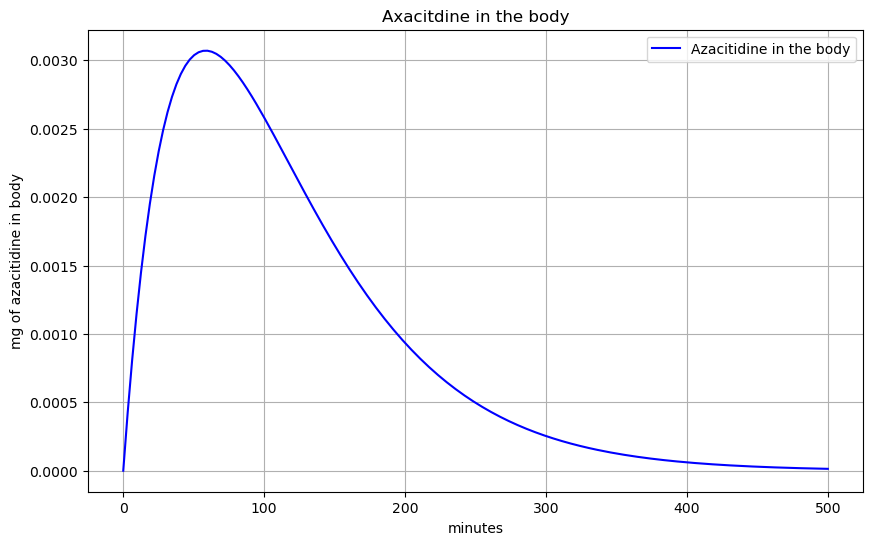

0.008250589495000274


"\nC= 0.075\n\ntp = np.linspace(1,500, 160) \nplt.figure(figsize=(10,6))\nxVal = tp\n#ret = odeint(plasma_Conct,y0,t)\n#C = ret.T\nplt.plot(xVal, plasma_Conct(tp), 'b', label='plasma conct')\nplt.legend()\nplt.grid(True)\nplt.show()\n"

In [26]:
import numpy as np
from scipy import integrate
from scipy.integrate import odeint
import matplotlib.pyplot as plt
def Aza_Effect(y,t,c1 = 0.1, c2 =0.1,p1 = 0.1,a1 = 0.875, d2 = 2.3):
    gut,out,Xl1, Xl2,Dead = y
    '''
        F = fraction absorbed by the body, bioavailability ~11% for oral dose
        ka = the first order absorption rate constant, 0.0173/min which was converted from 1.04/hr
        D0 = dose of the drug, 0.075 g
        k = rate constant of elimination  = ln(2)/halflife -> ln(2)/41mins = 0.0169
        C = volume of distribution, proportionality constant that relates the total amount of drug in the body to 
        plasma concentration at a single time. 
    '''
    F = 0.11
    ka = 0.0173
    D0 = 0.075
    k = 0.0169
    # rate of change in gut?  = rate of absorption - rate of elimination
    dgutdt =  F*ka*D0*np.exp(-ka*t) - k*gut
    doutdt = gut*np.exp(-((t-30)**2)/(2*np.exp(2)))
    klc = 1/(1+c2*Xl2) #the suppressive influence from nuetrophils and blasts in the blood
    dXl1dt = (2*a1*klc -1 - gut)*Xl1*p1 #change in leukemia cells in bone marrow 
    dXl2dt = 2*(1-a1*klc)*p1*Xl1 - (d2*Xl2)
    dXDeaddt = gut*Xl1
    #dgutdt = 0.075*np.exp(-0.023*t)
    return [dgutdt,doutdt,dXl1dt,dXl2dt, dXDeaddt]
#function that starts at zero, goes to 1 by t= 30 and then back down to 0 as t = 60. Does so relative to its amount

def plasma_Conct(t):
    
    F = 0.11
    ka = 0.0173
    D0 = 0.075
    k = 0.0169
    C = 110
    #this is the equation for the integral of the formula for amount of azacitidine in the body at a given time.
    #this gives the concentration of the drug in the plasma at any given time. 
    #Cp = (np.exp(-k*t)-np.exp(-ka*t))*(F*ka*D0)/(C*(ka-k))
    Cp = (np.exp(-k*t)-np.exp(-ka*t))*(F*ka*D0)/(C*(ka-k))
    return Cp

Gut =0
out = 0
N=1000
Xl1 =1000
Xl2 = 0
Dead = 0
t = np.linspace(0,500, 160)    
y0 = Gut,out,Xl1, Xl2,Dead
ret = odeint(Aza_Effect,y0,t)
Gut,out,Xl1, Xl2,Dead = ret.T
plt.figure(figsize=(10, 6))
plt.plot(t, Gut, 'b', label='Azacitidine in the body')
#plt.plot(t, out, 'r', label='Azacitidine')
#plt.plot(t, Xl2, 'r', label='Blast blood')
tb = np.linspace(0,500, 160)  

plt.title('Axacitdine in the body')
plt.xlabel('minutes')
plt.ylabel('mg of azacitidine in body')
plt.legend()
plt.grid(True)
plt.show()

print (integrate.trapezoid(Aza_Effect(y0,t)[0], t))
'''
C= 0.075

tp = np.linspace(1,500, 160) 
plt.figure(figsize=(10,6))
xVal = tp
#ret = odeint(plasma_Conct,y0,t)
#C = ret.T
plt.plot(xVal, plasma_Conct(tp), 'b', label='plasma conct')
plt.legend()
plt.grid(True)
plt.show()
'''
#plt.figure(figsize=(10, 6))
#plt.plot(tb, Xl2, 'r', label='Blasts in blood')
#plt.plot(tb, Xl1, 'g', label='Blasts in marrow')
#plt.plot(tb, Dead, 'b', label='Blasts killed by aza')

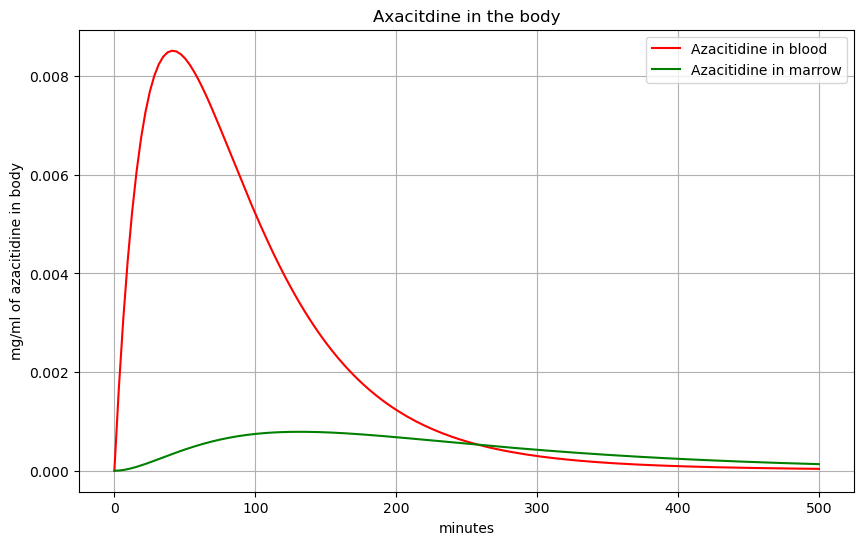

AUC of central compartment (blood) 1.0411946538739103
AUC of peripheralcompartment (bone marrow tissue) 0.22132813657150507


"\nC= 0.075\n\ntp = np.linspace(1,500, 160) \nplt.figure(figsize=(10,6))\nxVal = tp\n#ret = odeint(plasma_Conct,y0,t)\n#C = ret.T\nplt.plot(xVal, plasma_Conct(tp), 'b', label='plasma conct')\nplt.legend()\nplt.grid(True)\nplt.show()\n"

In [61]:
import numpy as np
from scipy.integrate import trapezoid 
from scipy.integrate import odeint
import matplotlib.pyplot as plt
def Aza_Effect(y,t,c1 = 0.1, c2 =0.1,p1 = 0.1,a1 = 0.875, d2 = 2.3):
    gut,C1,C2 = y
    '''
        F = fraction absorbed by the body, bioavailability ~11% for oral dose
        ka = the first order absorption rate constant, 0.0173/min which was converted from 1.04/hr
        D0 = dose of the drug, 0.075 g
        k = rate constant of elimination  = ln(2)/halflife -> ln(2)/30mins = 0.02310
        
    '''
    F = 0.11
    ka = 0.0173
    D0 = 0.300
    k = 0.02310
    V = 78
    S = 40
    k10 = 0.03151 #1.8902 #hr  #0.03151 in minutes   #1/hr (elimination rate)
    k12 = 0.00149  #0.0892  #assumption that the k12 is leaving so clearance into the peripheral to get the numbers - 
    k21 = 0.00641   #0.3847 (Q/volume of the intercompartment model)
    # rate of change in gut?  = rate of absorption - rate of elimination
    #the rate into gut is from https://pmc.ncbi.nlm.nih.gov/articles/PMC5750647/
    #dgutdt =  ((8.5*(10**-5))*(S-(gut/V)))-F*ka*D0*np.exp(-ka*t) 
    dgutdt = F*ka*D0*np.exp(-ka*t)
    dC1dt = F*ka*D0*np.exp(-ka*t) - (k10 + k12)*C1 + k21*C2 
    #dC1dt = (k0/V1) - (k10 + k12)*C1 + k21*C2
    dC2dt = k12*C1 - k21*C2
    dXDeaddt = gut*Xl1
    #dgutdt = 0.075*np.exp(-0.023*t)
    return [dgutdt,dC1dt,dC2dt]
#function that starts at zero, goes to 1 by t= 30 and then back down to 0 as t = 60. Does so relative to its amount

def plasma_Conct(t):
    
    F = 0.11
    ka = 0.0173
    D0 = 0.075
    k = 0.0169
    C = 110
    #this is the equation for the integral of the formula for amount of azacitidine in the body at a given time.
    #this gives the concentration of the drug in the plasma at any given time. 
    #Cp = (np.exp(-k*t)-np.exp(-ka*t))*(F*ka*D0)/(C*(ka-k))
    Cp = (np.exp(-k*t)-np.exp(-ka*t))*(F*ka*D0)/(C*(ka-k))
    return Cp



Gut =0
out = 0
N=1000
Xl1 =1000
Xl2 = 0
Dead = 0
C1 = 0
C2=0
t = np.linspace(0,500, 160)    
y0 = Gut,C1,C2
ret = odeint(Aza_Effect,y0,t)
Gut,C1,C2 = ret.T
plt.figure(figsize=(10, 6))
#plt.plot(t, Gut, 'b', label='Azacitidine in the body')
plt.plot(t, C1, 'r', label='Azacitidine in blood')
plt.plot(t, C2, 'g', label='Azacitidine in marrow')
#plt.plot(t, out, 'r', label='Azacitidine')
#plt.plot(t, Xl2, 'r', label='Blast blood')
tb = np.linspace(0,500, 160)  

plt.title('Axacitdine in the body')
plt.xlabel('minutes')
plt.ylabel('mg/ml of azacitidine in body')
plt.legend()
plt.grid(True)
plt.show()

auc_central = trapezoid(C1, t)     #np.trapezoid(C1, t) 
auc_peripheral = trapezoid(C2, t)         #np.trapezoid(C2, t) 
print ("AUC of central compartment (blood)", auc_central)
print ("AUC of peripheralcompartment (bone marrow tissue)", auc_peripheral)
'''
C= 0.075

tp = np.linspace(1,500, 160) 
plt.figure(figsize=(10,6))
xVal = tp
#ret = odeint(plasma_Conct,y0,t)
#C = ret.T
plt.plot(xVal, plasma_Conct(tp), 'b', label='plasma conct')
plt.legend()
plt.grid(True)
plt.show()
'''
#plt.figure(figsize=(10, 6))
#plt.plot(tb, Xl2, 'r', label='Blasts in blood')
#plt.plot(tb, Xl1, 'g', label='Blasts in marrow')
#plt.plot(tb, Dead, 'b', label='Blasts killed by aza')

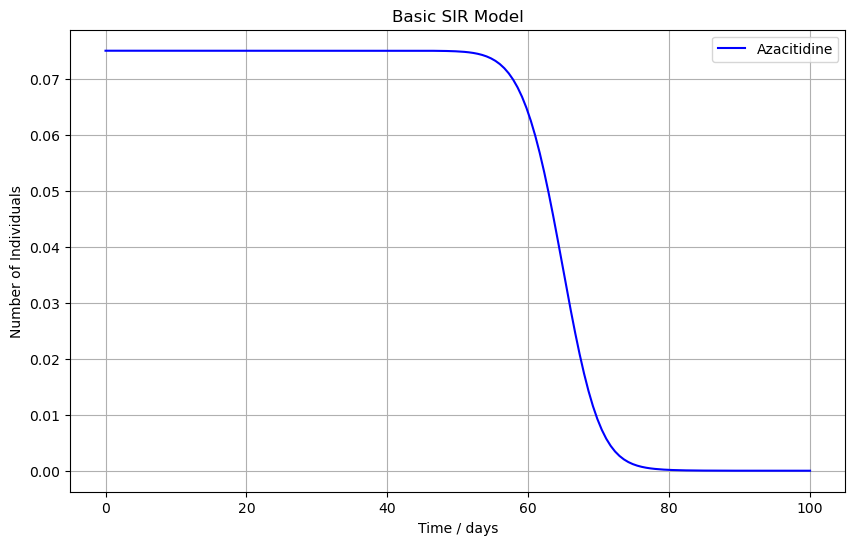

In [54]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
'''
    
    Xl1 = leukemic blasts in bone marrow
    Xl2 = leukemic blasts in the blood
    c1 and c2 = factor that modulates cytokine feedback, 0.1
    a1 = Fraction of self-renewal of leukemic cells, 0.875
    p1 = growth rate of leukemic cells, 0.1
    d2 = death rate of blasts in blood, 2.3
'''

gut = 0.075
out = 0
def Aza_Effect(y,t):
    gut,out = y
    
    dgutdt =  -gut*np.exp(-((t-30)**2)/(2*np.exp(2))) 
    doutdt = gut*np.exp(-((t-30)**2)/(2*np.exp(2)))
    #dgutdt = 0.075*np.exp(-0.023*t)
    return [dgutdt,doutdt]
    '''
        starts at zero but then after 0.5 hours it reaches its peak amount and then goes back down again until zero
        
    '''

ta = np.linspace(0,100, 160)    
ya = gut,out
ret = odeint(Aza_Effect,ya,ta)
gut,out = ret.T

    
Xl1 = 50000
Xl2=0



def blast_pop(y,t,c1 = 0.1, c2 =0.1,p1 = 0.1,a1 = 0.875, d2 = 2.3):#Blast population model in two compartments
     Xl1,Xl2 = y
     I = 0.075#mg dosage of azacitidine
     Eblast = I*np.exp(-0.023*t) #this is the decay of the dosage, assuming the dosage is proportional to effect on blast
     #the half life is assumed to be 41 minutes and the constant was found using ln(2)/41
     #klc = 1/(1+c1*Xwbc+c2*Xl2) #the suppressive influence from nuetrophils and blasts in the blood
     #dXl1dt = (a1 - Eblast)*Xl1 #change in leukemia cells in bone marrow 
     dXl1dt = Xl1*(1-gut)
     dXl2dt = 2*(1-a1)*p1*Xl1 - (d2*Xl2) #change in leukemia cells in blood
     return [dXl1dt, dXl2dt]

#t = np.linspace(0,41, 160)    
#y0 = Xl1,Xl2
#ret = odeint(blast_pop,y0,t)
#Xl1,Xl2 = ret.T
plt.figure(figsize=(10, 6))
#plt.plot(t, gut, 'b', label='Azacitidine')
#plt.plot(t, Xl2, 'r', label='Blast blood')
#plt.plot(t, Xl1, 'g', label='Blasts in marrow')
plt.title('Basic SIR Model')
plt.xlabel('Time / days')
plt.ylabel('Number of Individuals')
plt.legend()
plt.grid(True)
plt.show()